<a href="https://colab.research.google.com/github/tas0931/Pet-Image-Segmentation/blob/main/CSE428_project_attentionU_net_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1 — Mount Drive & Install Dependencies
from google.colab import drive
drive.mount('/content/drive')

!pip install albumentations -q

print(" Drive mounted & dependencies ready")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Drive mounted & dependencies ready


In [ ]:
# Cell 2 — Imports & Setup
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score)
import json
import time
import gc

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")
    print(f"   GPU RAM: "
          f"{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f" PyTorch : {torch.__version__}")

 Device : cuda
   GPU    : Tesla T4
   GPU RAM: 15.6 GB
 PyTorch : 2.10.0+cu128


In [ ]:
# Cell 3 — Paths & Class Names

IMAGE_DIR  = "/content/drive/MyDrive/cse428/Project Dataset/images"
ANNOT_DIR  = "/content/drive/MyDrive/cse428/Project Dataset/annotations"
TRIMAP_DIR = os.path.join(ANNOT_DIR, "trimaps")
TRAINVAL   = os.path.join(ANNOT_DIR, "trainval.txt")
TEST_FILE  = os.path.join(ANNOT_DIR, "test.txt")

for name, path in [("Images",      IMAGE_DIR),
                    ("Annotations", ANNOT_DIR),
                    ("Trimaps",     TRIMAP_DIR),
                    ("trainval",    TRAINVAL),
                    ("test",        TEST_FILE)]:
    print(f"{'' if os.path.exists(path) else ''} {name}: {path}")

# 37 class names (index 0 = class_id 1)
CLASS_NAMES = [
    "Abyssinian", "Bengal", "Birman", "Bombay", "British_Shorthair",
    "Egyptian_Mau", "Maine_Coon", "Persian", "Ragdoll", "Russian_Blue",
    "Siamese", "Sphynx", "american_bulldog", "american_pit_bull_terrier",
    "basset_hound", "beagle", "boxer", "chihuahua",
    "english_cocker_spaniel", "english_setter", "german_shorthaired",
    "great_pyrenees", "havanese", "japanese_chin", "keeshond",
    "leonberger", "miniature_pinscher", "newfoundland", "pomeranian",
    "pug", "saint_bernard", "samoyed", "scottish_terrier", "shiba_inu",
    "staffordshire_bull_terrier", "wheaten_terrier", "yorkshire_terrier"
]
ID_TO_CLASS  = {i+1: n for i, n in enumerate(CLASS_NAMES)}
SPECIES_MAP  = {1: "Cat", 2: "Dog"}

print(f"\n {len(CLASS_NAMES)} classes defined")

 Images: /content/drive/MyDrive/cse428/Project Dataset/images
 Annotations: /content/drive/MyDrive/cse428/Project Dataset/annotations
 Trimaps: /content/drive/MyDrive/cse428/Project Dataset/annotations/trimaps
 trainval: /content/drive/MyDrive/cse428/Project Dataset/annotations/trainval.txt
 test: /content/drive/MyDrive/cse428/Project Dataset/annotations/test.txt

 37 classes defined


In [ ]:
# Cell 4 — Parse Annotations & Build DataFrames

CORRUPT_FILES = {"beagle_116"}
PNG_FILES     = {"Egyptian_Mau_14", "Egyptian_Mau_156",
                 "Egyptian_Mau_186", "Abyssinian_5"}

def parse_file(filepath):
    rows = []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts      = line.split()
            stem       = parts[0]
            class_id   = int(parts[1])
            species_id = int(parts[2])
            if stem in CORRUPT_FILES:
                continue
            rows.append({
                "stem"        : stem,
                "class_id"    : class_id,
                "class_label" : class_id - 1,
                "class_name"  : ID_TO_CLASS[class_id],
                "species_id"  : species_id,
                "species"     : SPECIES_MAP[species_id],
            })
    return pd.DataFrame(rows)

df_trainval = parse_file(TRAINVAL)
df_test     = parse_file(TEST_FILE)

print(f" trainval : {len(df_trainval)} rows")
print(f" test     : {len(df_test)} rows")

 trainval : 3679 rows
 test     : 3669 rows


In [ ]:
# Cell 5 — Copy Dataset to Local SSD & Fix Paths

import shutil

LOCAL_IMAGE_DIR  = "/content/pet_data/images"
LOCAL_TRIMAP_DIR = "/content/pet_data/trimaps"
os.makedirs(LOCAL_IMAGE_DIR,  exist_ok=True)
os.makedirs(LOCAL_TRIMAP_DIR, exist_ok=True)

print("Copying images to local SSD (takes ~2-3 min)...")
start = time.time()
shutil.copytree(IMAGE_DIR,  LOCAL_IMAGE_DIR,  dirs_exist_ok=True)
print(f" Images  copied in {time.time()-start:.1f}s")

start = time.time()
shutil.copytree(TRIMAP_DIR, LOCAL_TRIMAP_DIR, dirs_exist_ok=True)
print(f" Trimaps copied in {time.time()-start:.1f}s")

# Build stem -- real path lookups (case-insensitive)
stem_to_image = {}
for fname in os.listdir(LOCAL_IMAGE_DIR):
    if fname.endswith((".jpg", ".jpeg", ".png")):
        stem_to_image[os.path.splitext(fname)[0].lower()] = \
            os.path.join(LOCAL_IMAGE_DIR, fname)

stem_to_mask = {}
for fname in os.listdir(LOCAL_TRIMAP_DIR):
    if fname.endswith(".png"):
        stem_to_mask[os.path.splitext(fname)[0].lower()] = \
            os.path.join(LOCAL_TRIMAP_DIR, fname)

# Apply paths to dataframes
for df in [df_trainval, df_test]:
    df['image_path'] = df['stem'].apply(
        lambda s: stem_to_image.get(s.lower()))
    df['mask_path']  = df['stem'].apply(
        lambda s: stem_to_mask.get(s.lower()))

# Drop any unmatched rows
before = len(df_trainval) + len(df_test)
df_trainval.dropna(subset=['image_path','mask_path'], inplace=True)
df_test.dropna(    subset=['image_path','mask_path'], inplace=True)
df_trainval.reset_index(drop=True, inplace=True)
df_test.reset_index(    drop=True, inplace=True)
after = len(df_trainval) + len(df_test)

print(f"\n Path lookup built")
print(f"   Images  on disk : {len(stem_to_image)}")
print(f"   Masks   on disk : {len(stem_to_mask)}")
print(f"   Dropped rows    : {before - after}")
print(f"   trainval usable : {len(df_trainval)}")
print(f"   test     usable : {len(df_test)}")

Copying images to local SSD (takes ~2-3 min)...
 Images  copied in 85.0s
 Trimaps copied in 155.9s

 Path lookup built
   Images  on disk : 7390
   Masks   on disk : 14780
   Dropped rows    : 0
   trainval usable : 3679
   test     usable : 3669


In [ ]:
# Cell 6 — Transforms, Dataset & DataLoaders

IMAGE_SIZE = 256
BATCH_SIZE = 8

# Transforms
train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1,
                       rotate_limit=15, border_mode=0, p=0.5),
    A.RandomResizedCrop(size=(IMAGE_SIZE, IMAGE_SIZE),
                        scale=(0.8, 1.0), ratio=(0.9, 1.1), p=0.4),
    A.Perspective(scale=(0.02, 0.05), p=0.3),
    A.ColorJitter(brightness=0.3, contrast=0.3,
                  saturation=0.2, hue=0.1, p=0.5),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_test_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

#  Dataset
class PetDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row     = self.df.iloc[idx]
        image   = np.array(Image.open(row['image_path']).convert("RGB"))
        raw_mask= np.array(Image.open(row['mask_path']))
        raw_mask[raw_mask == 3] = 1                      # boundary → fg
        mask    = (raw_mask == 1).astype(np.uint8)       # {0,1}

        if self.transform:
            out   = self.transform(image=image, mask=mask)
            image = out['image']
            mask  = out['mask']

        return image, mask.long(), int(row['class_label'])

    def get_sample_info(self, idx):
        row = self.df.iloc[idx]
        return {'stem'       : row['stem'],
                'class_name' : row['class_name'],
                'species'    : row['species'],
                'class_label': row['class_label']}

#  Train / Val split
df_train, df_val = train_test_split(
    df_trainval, test_size=0.2,
    random_state=SEED,
    stratify=df_trainval['class_label']
)
df_train.reset_index(drop=True, inplace=True)
df_val.reset_index(  drop=True, inplace=True)

#  DataLoaders
train_dataset = PetDataset(df_train, transform=train_transform)
val_dataset   = PetDataset(df_val,   transform=val_test_transform)
test_dataset  = PetDataset(df_test,  transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2,
                          pin_memory=True, drop_last=True,
                          persistent_workers=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2,
                          pin_memory=True,
                          persistent_workers=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2,
                          pin_memory=True,
                          persistent_workers=False)

print(f" Splits  — train:{len(df_train)} val:{len(df_val)} "
      f"test:{len(df_test)}")
print(f"Loaders — train:{len(train_loader)} batches | "
      f"val:{len(val_loader)} | test:{len(test_loader)}")

# Quick sanity check
imgs, masks, labels = next(iter(train_loader))
print(f" Batch   — images:{imgs.shape} masks:{masks.shape} "
      f"labels:{labels.shape}")

 Splits  — train:2943 val:736 test:3669
Loaders — train:367 batches | val:92 | test:459
 Batch   — images:torch.Size([8, 3, 256, 256]) masks:torch.Size([8, 256, 256]) labels:torch.Size([8])


In [ ]:
# Cell 7 — Attention U-Net Architecture

# DoubleConv
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

# Encoder Block
class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = DoubleConv(in_ch, out_ch)
        self.pool = nn.MaxPool2d(2, 2)
    def forward(self, x):
        skip = self.conv(x)
        return skip, self.pool(skip)

#  Attention Gate
class AttentionGate(nn.Module):
    """
    Reweights skip connection features using a gating signal.
    Suppresses irrelevant background regions, focuses on pet.
    """
    def __init__(self, F_g, F_x, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g,  F_int, 1, bias=False),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_x,  F_int, 1, bias=False),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        if g1.shape[2:] != x1.shape[2:]:
            g1 = F.interpolate(g1, size=x1.shape[2:],
                               mode='bilinear', align_corners=False)
        return x * self.psi(self.relu(g1 + x1))

# Attention Decoder Block
class AttentionDecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.attn = AttentionGate(F_g=out_ch, F_x=skip_ch,
                                  F_int=skip_ch // 2)
        self.conv = DoubleConv(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:],
                              mode='bilinear', align_corners=False)
        skip = self.attn(g=x, x=skip)
        return self.conv(torch.cat([skip, x], dim=1))

# Full Attention U-Net
class AttentionUNet(nn.Module):
    """
    Attention U-Net with classifier head attached to bottleneck.
    Encoder + Bottleneck identical to Base U-Net.
    Decoder uses Attention Gates on all skip connections.

    Outputs:
        seg_logits : [B, 1,  256, 256]  binary segmentation
        cls_logits : [B, 37]            breed classification
    """
    def __init__(self, in_channels=3, num_classes=37):
        super().__init__()
        self.enc1       = EncoderBlock(in_channels, 64)
        self.enc2       = EncoderBlock(64,  128)
        self.enc3       = EncoderBlock(128, 256)
        self.enc4       = EncoderBlock(256, 512)
        self.bottleneck = DoubleConv(512, 1024)
        self.dec4       = AttentionDecoderBlock(1024, 512, 512)
        self.dec3       = AttentionDecoderBlock(512,  256, 256)
        self.dec2       = AttentionDecoderBlock(256,  128, 128)
        self.dec1       = AttentionDecoderBlock(128,  64,  64)
        self.seg_head   = nn.Conv2d(64, 1, kernel_size=1)
        self.cls_head   = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        skip1, x = self.enc1(x)
        skip2, x = self.enc2(x)
        skip3, x = self.enc3(x)
        skip4, x = self.enc4(x)
        x        = self.bottleneck(x)
        cls_logits = self.cls_head(x)
        x = self.dec4(x, skip4)
        x = self.dec3(x, skip3)
        x = self.dec2(x, skip2)
        x = self.dec1(x, skip1)
        return self.seg_head(x), cls_logits

#Verify
attn_model = AttentionUNet(in_channels=3, num_classes=37).to(DEVICE)
with torch.no_grad():
    dummy      = torch.randn(2, 3, 256, 256).to(DEVICE)
    seg_o, cls_o = attn_model(dummy)
    del dummy
    torch.cuda.empty_cache()

total_p = sum(p.numel() for p in attn_model.parameters())
print(f" Attention U-Net verified")
print(f"   Seg output : {seg_o.shape}")
print(f"   Cls output : {cls_o.shape}")
print(f"   Parameters : {total_p:,}")
print(f"   GPU RAM    : "
      f"{torch.cuda.memory_allocated(0)/1e9:.2f} GB used")

 Attention U-Net verified
   Seg output : torch.Size([2, 1, 256, 256])
   Cls output : torch.Size([2, 37])
   Parameters : 31,931,982
   GPU RAM    : 0.28 GB used


In [ ]:
# Cell 8 — Loss Functions & Metrics

#Dice Loss
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    def forward(self, logits, targets):
        probs  = torch.sigmoid(logits).squeeze(1)
        tgts   = targets.float()
        inter  = (probs * tgts).sum(dim=(1,2))
        union  = probs.sum(dim=(1,2)) + tgts.sum(dim=(1,2))
        return 1 - ((2*inter + self.smooth) / (union + self.smooth)).mean()

#Combined Seg Loss: BCE + Dice
class CombinedSegLoss(nn.Module):
    def __init__(self, bce_w=0.5, dice_w=0.5):
        super().__init__()
        self.bce_w  = bce_w
        self.dice_w = dice_w
        self.bce    = nn.BCEWithLogitsLoss()
        self.dice   = DiceLoss()
    def forward(self, logits, targets):
        return (self.bce_w  * self.bce(logits, targets.float().unsqueeze(1)) +
                self.dice_w * self.dice(logits, targets))

seg_criterion = CombinedSegLoss(bce_w=0.5, dice_w=0.5)
cls_criterion = nn.CrossEntropyLoss()

#Segmentation Metrics
def compute_seg_metrics(logits, targets, threshold=0.5):
    preds = (torch.sigmoid(logits).squeeze(1) > threshold).long()
    p = preds.cpu().numpy().flatten()
    t = targets.cpu().numpy().flatten()
    inter = np.logical_and(p==1, t==1).sum()
    union = np.logical_or( p==1, t==1).sum()
    iou   = (inter + 1e-6) / (union + 1e-6)
    dice  = (2*inter + 1e-6) / (p.sum() + t.sum() + 1e-6)
    return {'iou': iou, 'dice': dice, 'pixel_acc': (p==t).mean()}

#Classification Metrics
def compute_cls_metrics(logits, targets):
    p = logits.argmax(dim=1).cpu().numpy()
    t = targets.cpu().numpy()
    return {
        'acc'      : accuracy_score(t, p),
        'precision': precision_score(t, p, average='macro', zero_division=0),
        'recall'   : recall_score(   t, p, average='macro', zero_division=0),
        'f1'       : f1_score(       t, p, average='macro', zero_division=0),
    }

print(" Loss functions : BCE + Dice (seg) | CrossEntropy (cls)")
print(" Metrics        : IoU, Dice, PixAcc | Acc, Prec, Recall, F1")

 Loss functions : BCE + Dice (seg) | CrossEntropy (cls)
 Metrics        : IoU, Dice, PixAcc | Acc, Prec, Recall, F1


In [ ]:
# Cell 9—Training & Evaluation Functions

SEG_LOSS_W = 1.0
CLS_LOSS_W = 0.5

def train_one_epoch(model, loader, optimizer,
                    seg_crit, cls_crit, device,
                    metric_every=5):
    model.train()
    total_loss = seg_losses = cls_losses = 0.0
    all_seg = {'iou':[], 'dice':[], 'pixel_acc':[]}
    all_cls = {'acc':[], 'precision':[], 'recall':[], 'f1':[]}

    for i, (imgs, masks, labels) in enumerate(loader):
        imgs   = imgs.to(device,   non_blocking=True)
        masks  = masks.to(device,  non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        seg_log, cls_log = model(imgs)
        seg_l = seg_crit(seg_log, masks)
        cls_l = cls_crit(cls_log, labels)
        loss  = SEG_LOSS_W * seg_l + CLS_LOSS_W * cls_l
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        seg_losses += seg_l.item()
        cls_losses += cls_l.item()

        if i % metric_every == 0:
            with torch.no_grad():
                sm = compute_seg_metrics(seg_log, masks)
                cm = compute_cls_metrics(cls_log, labels)
                for k in all_seg: all_seg[k].append(sm[k])
                for k in all_cls: all_cls[k].append(cm[k])

    n = len(loader)
    return {'total_loss': total_loss/n, 'seg_loss': seg_losses/n,
            'cls_loss': cls_losses/n,
            'iou': np.mean(all_seg['iou']),
            'dice': np.mean(all_seg['dice']),
            'pixel_acc': np.mean(all_seg['pixel_acc']),
            'cls_acc': np.mean(all_cls['acc']),
            'precision': np.mean(all_cls['precision']),
            'recall': np.mean(all_cls['recall']),
            'f1': np.mean(all_cls['f1'])}

@torch.no_grad()
def evaluate(model, loader, seg_crit, cls_crit, device):
    model.eval()
    total_loss = seg_losses = cls_losses = 0.0
    all_seg = {'iou':[], 'dice':[], 'pixel_acc':[]}
    all_cls = {'acc':[], 'precision':[], 'recall':[], 'f1':[]}

    for imgs, masks, labels in loader:
        imgs   = imgs.to(device,   non_blocking=True)
        masks  = masks.to(device,  non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        seg_log, cls_log = model(imgs)
        seg_l = seg_crit(seg_log, masks)
        cls_l = cls_crit(cls_log, labels)
        loss  = SEG_LOSS_W * seg_l + CLS_LOSS_W * cls_l
        total_loss += loss.item()
        seg_losses += seg_l.item()
        cls_losses += cls_l.item()
        sm = compute_seg_metrics(seg_log, masks)
        cm = compute_cls_metrics(cls_log, labels)
        for k in all_seg: all_seg[k].append(sm[k])
        for k in all_cls: all_cls[k].append(cm[k])

    n = len(loader)
    return {'total_loss': total_loss/n, 'seg_loss': seg_losses/n,
            'cls_loss': cls_losses/n,
            'iou': np.mean(all_seg['iou']),
            'dice': np.mean(all_seg['dice']),
            'pixel_acc': np.mean(all_seg['pixel_acc']),
            'cls_acc': np.mean(all_cls['acc']),
            'precision': np.mean(all_cls['precision']),
            'recall': np.mean(all_cls['recall']),
            'f1': np.mean(all_cls['f1'])}

print(" train_one_epoch() defined")
print(" evaluate() defined")

 train_one_epoch() defined
 evaluate() defined


In [ ]:
# Cell 10—Training Setup

NUM_EPOCHS     = 50
LR             = 1e-3
PATIENCE       = 10
best_attn_path = '/content/drive/MyDrive/cse428/best_attn_unet.pth'

#Attention U-Net
attn_model = AttentionUNet(in_channels=3, num_classes=37).to(DEVICE)

attn_optimizer = torch.optim.Adam(
    attn_model.parameters(), lr=LR, weight_decay=1e-4
)
attn_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    attn_optimizer, mode='min', factor=0.5, patience=5
)

print(f" Attention U-Net training setup:")
print(f"   Epochs      : {NUM_EPOCHS}")
print(f"   Batch size  : {BATCH_SIZE}")
print(f"   LR          : {LR}")
print(f"   Optimizer   : Adam (wd=1e-4)")
print(f"   Scheduler   : ReduceLROnPlateau (p=5, f=0.5)")
print(f"   Early stop  : patience={PATIENCE}")
print(f"   Save path   : {best_attn_path}")
print(f"   GPU RAM used: "
      f"{torch.cuda.memory_allocated(0)/1e9:.2f} GB / "
      f"{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

 Attention U-Net training setup:
   Epochs      : 50
   Batch size  : 8
   LR          : 0.001
   Optimizer   : Adam (wd=1e-4)
   Scheduler   : ReduceLROnPlateau (p=5, f=0.5)
   Early stop  : patience=10
   Save path   : /content/drive/MyDrive/cse428/best_attn_unet.pth
   GPU RAM used: 0.68 GB / 15.6 GB


In [ ]:
# Cell 11 — Run Attention U-Net Training

history = {
    'train': {k:[] for k in ['total_loss','seg_loss','cls_loss',
                              'iou','dice','pixel_acc',
                              'cls_acc','precision','recall','f1']},
    'val'  : {k:[] for k in ['total_loss','seg_loss','cls_loss',
                              'iou','dice','pixel_acc',
                              'cls_acc','precision','recall','f1']}
}

best_val_loss = float('inf')
no_improve    = 0

print("=" * 75)
print(" ATTENTION U-NET TRAINING")
print("=" * 75)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    tr = train_one_epoch(attn_model, train_loader,
                         attn_optimizer, seg_criterion,
                         cls_criterion, DEVICE)
    vl = evaluate(attn_model, val_loader,
                  seg_criterion, cls_criterion, DEVICE)

    attn_scheduler.step(vl['total_loss'])

    for k in history['train']:
        history['train'][k].append(tr[k])
        history['val'][k].append(vl[k])

    if vl['total_loss'] < best_val_loss:
        best_val_loss = vl['total_loss']
        torch.save(attn_model.state_dict(), best_attn_path)
        no_improve = 0
        flag = "s"
    else:
        no_improve += 1
        flag = ""

    print(f"Ep[{epoch:02d}/{NUM_EPOCHS}] {time.time()-t0:.0f}s | "
          f"TrLoss:{tr['total_loss']:.3f} "
          f"VaLoss:{vl['total_loss']:.3f} | "
          f"IoU:{vl['iou']:.3f} "
          f"Dice:{vl['dice']:.3f} "
          f"PixAcc:{vl['pixel_acc']:.3f} | "
          f"ClsAcc:{vl['cls_acc']:.3f} "
          f"F1:{vl['f1']:.3f} {flag}")

    if no_improve >= PATIENCE:
        print(f"\n⏹️  Early stopping at epoch {epoch}")
        break

hist_path = '/content/drive/MyDrive/cse428/attn_unet_history.json'
with open(hist_path, 'w') as f:
    json.dump(history, f)

print(f"\n Training complete — best val loss : {best_val_loss:.4f}")
print(f"   Model saved   : {best_attn_path}")
print(f"   History saved : {hist_path}")

 ATTENTION U-NET TRAINING
Ep[01/50] 207s | TrLoss:2.249 VaLoss:2.282 | IoU:0.572 Dice:0.726 PixAcc:0.748 | ClsAcc:0.027 F1:0.006 s
Ep[02/50] 206s | TrLoss:2.226 VaLoss:2.193 | IoU:0.626 Dice:0.769 PixAcc:0.805 | ClsAcc:0.027 F1:0.007 s
Ep[03/50] 206s | TrLoss:2.203 VaLoss:2.181 | IoU:0.639 Dice:0.779 PixAcc:0.819 | ClsAcc:0.024 F1:0.009 s
Ep[04/50] 206s | TrLoss:2.193 VaLoss:2.196 | IoU:0.626 Dice:0.768 PixAcc:0.815 | ClsAcc:0.027 F1:0.007 
Ep[05/50] 206s | TrLoss:2.179 VaLoss:2.176 | IoU:0.631 Dice:0.772 PixAcc:0.806 | ClsAcc:0.027 F1:0.007 s
Ep[06/50] 205s | TrLoss:2.161 VaLoss:2.123 | IoU:0.676 Dice:0.805 PixAcc:0.834 | ClsAcc:0.033 F1:0.013 s
Ep[07/50] 204s | TrLoss:2.124 VaLoss:2.148 | IoU:0.682 Dice:0.809 PixAcc:0.838 | ClsAcc:0.029 F1:0.015 
Ep[08/50] 204s | TrLoss:2.104 VaLoss:2.091 | IoU:0.653 Dice:0.788 PixAcc:0.839 | ClsAcc:0.043 F1:0.020 s
Ep[09/50] 204s | TrLoss:2.087 VaLoss:2.063 | IoU:0.698 Dice:0.821 PixAcc:0.849 | ClsAcc:0.054 F1:0.028 s
Ep[10/50] 203s | TrLoss:2.069 V

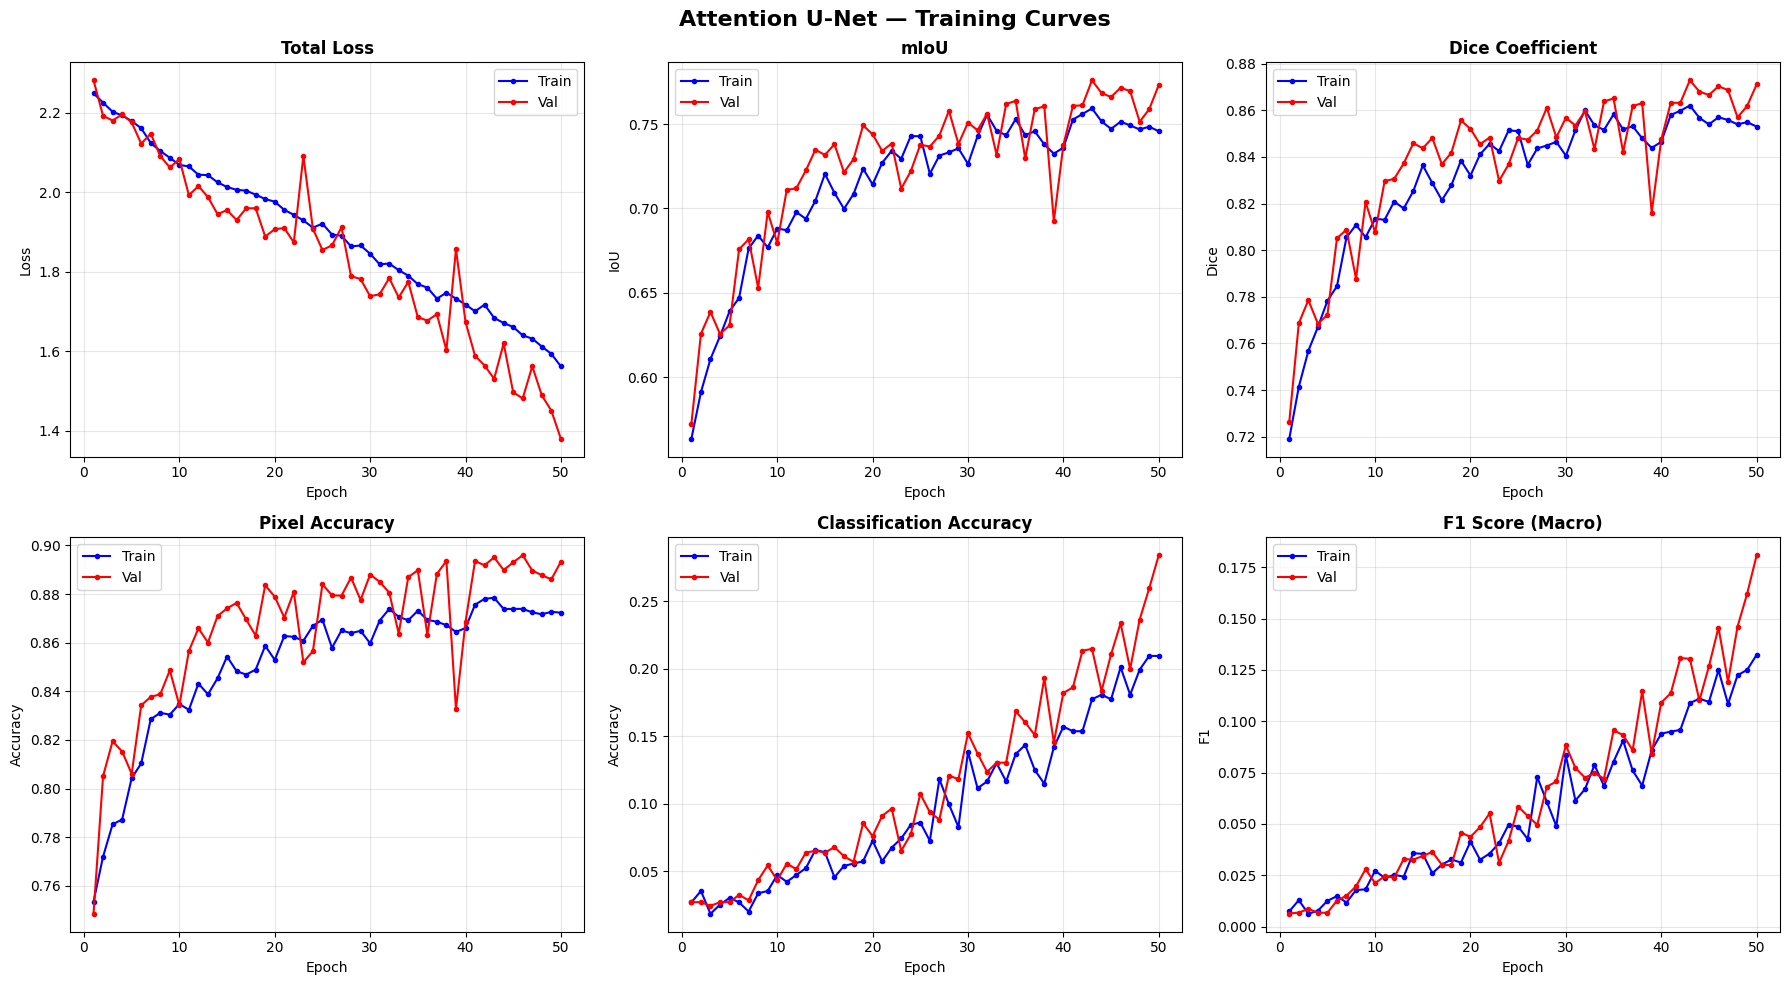

 Training curves saved to Drive


In [ ]:
# Cell 12 — Training Curves

epochs_ran = len(history['train']['total_loss'])
x = range(1, epochs_ran + 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Attention U-Net — Training Curves",
             fontsize=16, fontweight='bold')

plots = [
    ('total_loss', 'Total Loss',             'Loss'),
    ('iou',        'mIoU',                   'IoU'),
    ('dice',       'Dice Coefficient',        'Dice'),
    ('pixel_acc',  'Pixel Accuracy',          'Accuracy'),
    ('cls_acc',    'Classification Accuracy', 'Accuracy'),
    ('f1',         'F1 Score (Macro)',        'F1'),
]

for ax, (key, title, ylabel) in zip(axes.flatten(), plots):
    ax.plot(x, history['train'][key], 'b-o',
            markersize=3, linewidth=1.5, label='Train')
    ax.plot(x, history['val'][key],   'r-o',
            markersize=3, linewidth=1.5, label='Val')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cse428/attn_unet_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Cell 13 — Load Best Model & Evaluate on All Sets


attn_model.load_state_dict(
    torch.load(best_attn_path, map_location=DEVICE)
)
attn_model.eval()
print(f" Best Attention U-Net loaded\n")

#Evaluate all splits
results = {}
for name, loader in [('TRAIN', train_loader),
                      ('VAL',   val_loader),
                      ('TEST',  test_loader)]:
    results[name] = evaluate(attn_model, loader,
                             seg_criterion, cls_criterion, DEVICE)


def print_results(split, r):
    print(f"\n{'─'*50}")
    print(f"  {split}")
    print(f"{'─'*50}")
    print(f"  SEGMENTATION")
    print(f"    mIoU           : {r['iou']:.4f}")
    print(f"    Dice           : {r['dice']:.4f}")
    print(f"    Pixel Accuracy : {r['pixel_acc']:.4f}")
    print(f"  CLASSIFICATION")
    print(f"    Accuracy       : {r['cls_acc']:.4f}")
    print(f"    Precision      : {r['precision']:.4f}")
    print(f"    Recall         : {r['recall']:.4f}")
    print(f"    F1 Score       : {r['f1']:.4f}")

print("=" * 50)
print("  ATTENTION U-NET — FINAL RESULT SUMMARY")
print("=" * 50)
for split in ['TRAIN', 'VAL', 'TEST']:
    print_results(f"{split} SET", results[split])
print(f"\n{'='*50}")

# Verdict
def grade(v, poor, ok, good):
    if v >= good: return " Great"
    if v >= ok:   return " Good"
    if v >= poor: return " Acceptable"
    return               " Poor"

r = results['TEST']
print(f"\n  VERDICT (Test Set)")
print(f"  mIoU       : {r['iou']:.4f}  "
      f"{grade(r['iou'],      0.60, 0.70, 0.80)}")
print(f"  Dice       : {r['dice']:.4f}  "
      f"{grade(r['dice'],     0.70, 0.80, 0.88)}")
print(f"  Pixel Acc  : {r['pixel_acc']:.4f}  "
      f"{grade(r['pixel_acc'],0.85, 0.90, 0.94)}")
print(f"  Cls Acc    : {r['cls_acc']:.4f}  "
      f"{grade(r['cls_acc'],  0.40, 0.60, 0.75)}")
print(f"  F1 Score   : {r['f1']:.4f}  "
      f"{grade(r['f1'],       0.35, 0.55, 0.70)}")

 Best Attention U-Net loaded

  ATTENTION U-NET — FINAL RESULT SUMMARY

──────────────────────────────────────────────────
  TRAIN SET
──────────────────────────────────────────────────
  SEGMENTATION
    mIoU           : 0.7617
    Dice           : 0.8636
    Pixel Accuracy : 0.8809
  CLASSIFICATION
    Accuracy       : 0.3031
    Precision      : 0.1981
    Recall         : 0.2034
    F1 Score       : 0.1962

──────────────────────────────────────────────────
  VAL SET
──────────────────────────────────────────────────
  SEGMENTATION
    mIoU           : 0.7732
    Dice           : 0.8711
    Pixel Accuracy : 0.8933
  CLASSIFICATION
    Accuracy       : 0.2840
    Precision      : 0.1805
    Recall         : 0.1906
    F1 Score       : 0.1808

──────────────────────────────────────────────────
  TEST SET
──────────────────────────────────────────────────
  SEGMENTATION
    mIoU           : 0.7889
    Dice           : 0.8806
    Pixel Accuracy : 0.8995
  CLASSIFICATION
    Accuracy   

Attention U-Net — Prediction Visualizations (Test Set)

Sample 1:


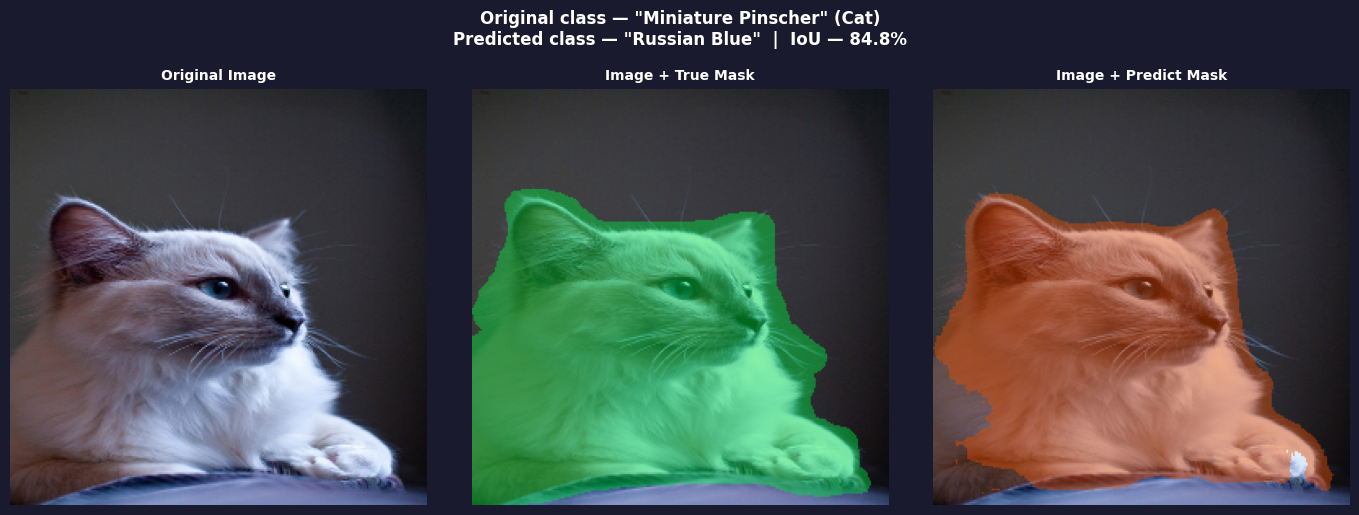

  IoU = 84.8%

Sample 2:


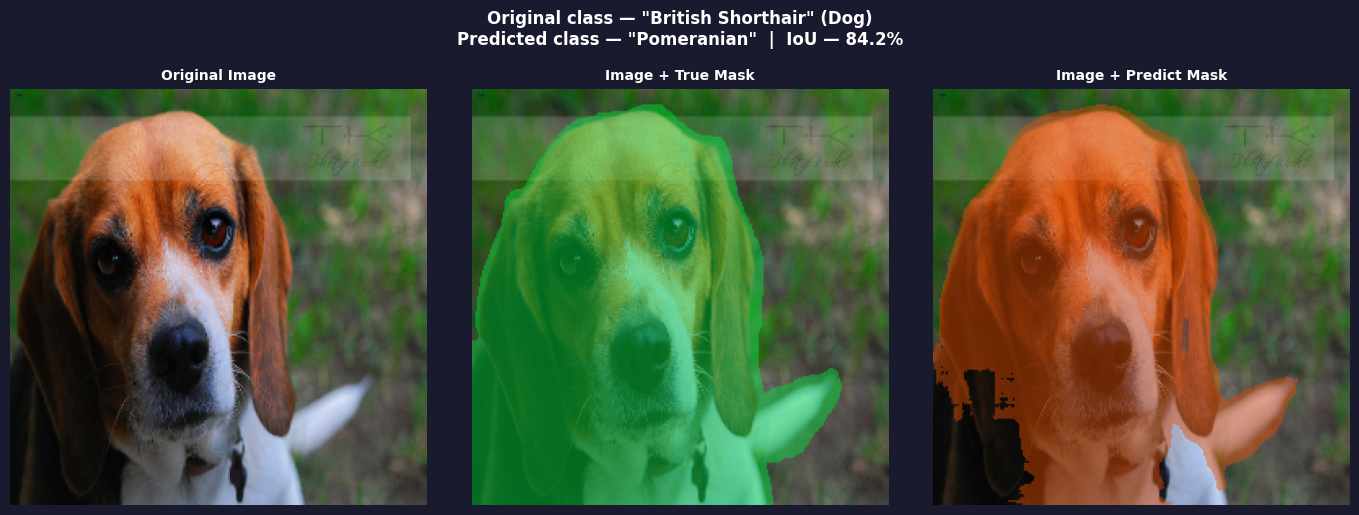

  IoU = 84.2%

Sample 3:


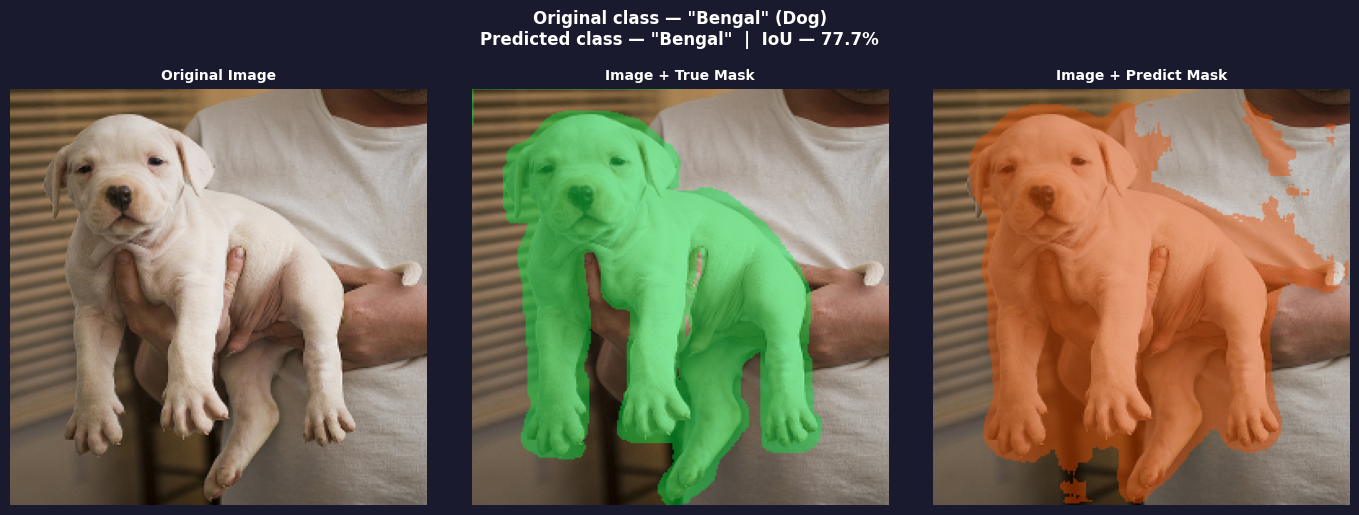

  IoU = 77.7%



In [ ]:
# Cell 14 — 3-Panel Prediction Visualization

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

def denormalize(tensor):
    img = tensor.permute(1,2,0).cpu().numpy()
    return np.clip(img * IMAGENET_STD + IMAGENET_MEAN, 0, 1)

def make_overlay(img, mask, color, alpha=0.45):
    out = img.copy()
    for c, v in enumerate(color):
        out[:,:,c] = np.where(mask==1,
                               out[:,:,c]*(1-alpha) + v*alpha,
                               out[:,:,c])
    return np.clip(out, 0, 1)

@torch.no_grad()
def visualize_prediction(model, dataset, idx, device):
    model.eval()
    image, mask, true_label = dataset[idx]
    info = dataset.get_sample_info(idx)

    seg_log, cls_log = model(image.unsqueeze(0).to(device))
    pred_mask  = (torch.sigmoid(seg_log)
                  .squeeze().cpu().numpy() > 0.5).astype(np.uint8)
    pred_label = cls_log.argmax(dim=1).item()
    true_mask  = mask.cpu().numpy()

    inter = np.logical_and(pred_mask==1, true_mask==1).sum()
    union = np.logical_or( pred_mask==1, true_mask==1).sum()
    iou   = (inter + 1e-6) / (union + 1e-6)

    img_np   = denormalize(image)
    true_ov  = make_overlay(img_np, true_mask,
                             (0,    0.9, 0.25))   # green
    pred_ov  = make_overlay(img_np, pred_mask,
                             (0.9,  0.3, 0   ))   # orange

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    fig.patch.set_facecolor('#1a1a2e')

    true_name = CLASS_NAMES[true_label].replace("_"," ").title()
    pred_name = CLASS_NAMES[pred_label].replace("_"," ").title()

    fig.suptitle(
        f'Original class — "{true_name}" ({info["species"]})\n'
        f'Predicted class — "{pred_name}"  |  IoU — {iou*100:.1f}%',
        fontsize=12, fontweight='bold', color='white', y=1.02
    )

    for ax, img, title in zip(
        axes,
        [img_np,   true_ov,              pred_ov],
        ['Original Image', 'Image + True Mask', 'Image + Predict Mask']
    ):
        ax.imshow(img)
        ax.set_title(title, fontsize=10,
                     fontweight='bold', color='white')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(
        f'/content/drive/MyDrive/cse428/'
        f'attn_pred_{idx}.png',
        dpi=120, bbox_inches='tight'
    )
    plt.show()
    return iou

# Run on random test samples
print("Attention U-Net — Prediction Visualizations (Test Set)\n")
random.seed(SEED)
test_indices = random.sample(range(len(test_dataset)), 3)

for i, idx in enumerate(test_indices):
    print(f"Sample {i+1}:")
    iou = visualize_prediction(attn_model, test_dataset, idx, DEVICE)
    print(f"  IoU = {iou*100:.1f}%\n")

Demo part for any image

In [ ]:
# DEMO SETUP CELL

from google.colab import drive
drive.mount('/content/drive')

!pip install albumentations -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Device: {DEVICE}")

# 37 class names
CLASS_NAMES = [
    "Abyssinian", "Bengal", "Birman", "Bombay", "British_Shorthair",
    "Egyptian_Mau", "Maine_Coon", "Persian", "Ragdoll", "Russian_Blue",
    "Siamese", "Sphynx", "american_bulldog", "american_pit_bull_terrier",
    "basset_hound", "beagle", "boxer", "chihuahua",
    "english_cocker_spaniel", "english_setter", "german_shorthaired",
    "great_pyrenees", "havanese", "japanese_chin", "keeshond",
    "leonberger", "miniature_pinscher", "newfoundland", "pomeranian",
    "pug", "saint_bernard", "samoyed", "scottish_terrier", "shiba_inu",
    "staffordshire_bull_terrier", "wheaten_terrier", "yorkshire_terrier"
]

# Model architectures
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = DoubleConv(in_ch, out_ch)
        self.pool = nn.MaxPool2d(2, 2)
    def forward(self, x):
        skip = self.conv(x)
        return skip, self.pool(skip)

class DecoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:],
                              mode='bilinear', align_corners=False)
        return self.conv(torch.cat([skip, x], dim=1))

class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=37):
        super().__init__()
        self.enc1       = EncoderBlock(in_channels, 64)
        self.enc2       = EncoderBlock(64,  128)
        self.enc3       = EncoderBlock(128, 256)
        self.enc4       = EncoderBlock(256, 512)
        self.bottleneck = DoubleConv(512, 1024)
        self.dec4       = DecoderBlock(1024, 512)
        self.dec3       = DecoderBlock(512,  256)
        self.dec2       = DecoderBlock(256,  128)
        self.dec1       = DecoderBlock(128,  64)
        self.seg_head   = nn.Conv2d(64, 1, kernel_size=1)
        self.cls_head   = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(1024, 512), nn.ReLU(inplace=True),
            nn.Dropout(0.4), nn.Linear(512, num_classes)
        )
    def forward(self, x):
        s1, x = self.enc1(x)
        s2, x = self.enc2(x)
        s3, x = self.enc3(x)
        s4, x = self.enc4(x)
        x     = self.bottleneck(x)
        cls   = self.cls_head(x)
        x     = self.dec4(x, s4)
        x     = self.dec3(x, s3)
        x     = self.dec2(x, s2)
        x     = self.dec1(x, s1)
        return self.seg_head(x), cls

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_x, F_int):
        super().__init__()
        self.W_g  = nn.Sequential(nn.Conv2d(F_g,  F_int, 1, bias=False),
                                   nn.BatchNorm2d(F_int))
        self.W_x  = nn.Sequential(nn.Conv2d(F_x,  F_int, 1, bias=False),
                                   nn.BatchNorm2d(F_int))
        self.psi  = nn.Sequential(nn.Conv2d(F_int, 1, 1, bias=False),
                                   nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        if g1.shape[2:] != x1.shape[2:]:
            g1 = F.interpolate(g1, size=x1.shape[2:],
                               mode='bilinear', align_corners=False)
        return x * self.psi(self.relu(g1 + x1))

class AttentionDecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.attn = AttentionGate(F_g=out_ch, F_x=skip_ch,
                                  F_int=skip_ch//2)
        self.conv = DoubleConv(out_ch + skip_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:],
                              mode='bilinear', align_corners=False)
        return self.conv(torch.cat([self.attn(g=x, x=skip), x], dim=1))

class AttentionUNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=37):
        super().__init__()
        self.enc1       = EncoderBlock(in_channels, 64)
        self.enc2       = EncoderBlock(64,  128)
        self.enc3       = EncoderBlock(128, 256)
        self.enc4       = EncoderBlock(256, 512)
        self.bottleneck = DoubleConv(512, 1024)
        self.dec4       = AttentionDecoderBlock(1024, 512, 512)
        self.dec3       = AttentionDecoderBlock(512,  256, 256)
        self.dec2       = AttentionDecoderBlock(256,  128, 128)
        self.dec1       = AttentionDecoderBlock(128,  64,  64)
        self.seg_head   = nn.Conv2d(64, 1, kernel_size=1)
        self.cls_head   = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(1024, 512), nn.ReLU(inplace=True),
            nn.Dropout(0.4), nn.Linear(512, num_classes)
        )
    def forward(self, x):
        s1, x = self.enc1(x)
        s2, x = self.enc2(x)
        s3, x = self.enc3(x)
        s4, x = self.enc4(x)
        x     = self.bottleneck(x)
        cls   = self.cls_head(x)
        x     = self.dec4(x, s4)
        x     = self.dec3(x, s3)
        x     = self.dec2(x, s2)
        x     = self.dec1(x, s1)
        return self.seg_head(x), cls

print(" UNet & AttentionUNet architectures defined")
print(" CLASS_NAMES defined (37 breeds)")

Mounted at /content/drive
 Device: cpu
 UNet & AttentionUNet architectures defined
 CLASS_NAMES defined (37 breeds)


 Attention U-Net loaded from: /content/drive/MyDrive/cse428/best_attn_unet.pth
 run_demo() defined


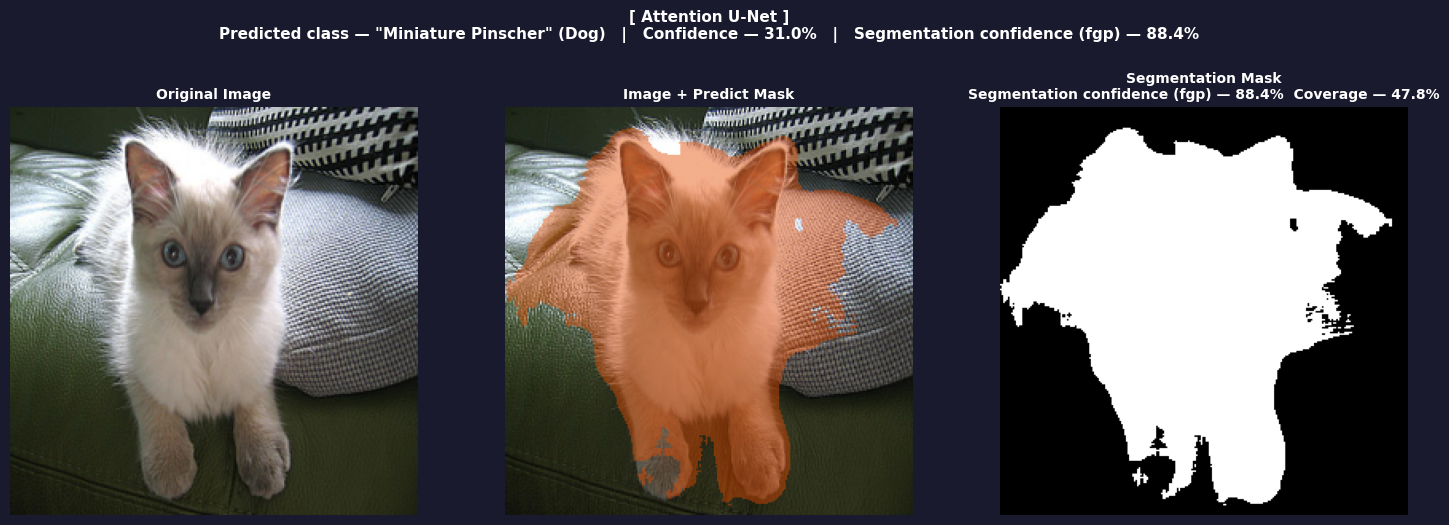

  Attention U-Net — PREDICTION SUMMARY
  CLASSIFICATION
    Predicted Breed   : Miniature Pinscher
    Predicted Species : Dog
    Confidence        : 31.0%

  SEGMENTATION
     Segmentation confidence(I)              : 88.4%
    Foreground pixels : 31344 / 65536
    Foreground cover  : 47.8% of image


In [ ]:
# DEMO CELL 2 — Attention U-Net Prediction on Any Given Image

IMAGE_PATH = "/content/drive/MyDrive/cse428/test_image.jpg"


best_attn_path = '/content/drive/MyDrive/cse428/best_attn_unet.pth'

# Load Attention U-Net
attn_model = AttentionUNet(in_channels=3, num_classes=37).to(DEVICE)
attn_model.load_state_dict(
    torch.load(best_attn_path, map_location=DEVICE)
)
attn_model.eval()
print(f" Attention U-Net loaded from: {best_attn_path}")

def load_image_for_inference(image_path):
    img          = Image.open(image_path).convert("RGB")
    original_img = np.array(img)
    transform    = A.Compose([
        A.Resize(256, 256),
        A.Normalize(mean=[0.485, 0.456, 0.406],
                    std =[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])
    tensor = transform(image=original_img)['image']
    return original_img, tensor

@torch.no_grad()
def run_demo(model, image_path, model_name, device):
    model.eval()
    original_img, img_tensor = load_image_for_inference(image_path)
    display_img = np.array(
        Image.fromarray(original_img).resize((256, 256))
    )

    inp                    = img_tensor.unsqueeze(0).to(device)
    seg_logits, cls_logits = model(inp)

    #Segmentation
    seg_prob  = torch.sigmoid(seg_logits).squeeze().cpu().numpy()
    pred_mask = (seg_prob > 0.5).astype(np.uint8)

    fg         = pred_mask.sum()
    bg         = (pred_mask == 0).sum()
    total      = pred_mask.size
    pred_iou   = (fg + 1e-6) / (total + 1e-6) * 100

    fg_probs       = seg_prob[pred_mask == 1]
    confidence_iou = float(fg_probs.mean() * 100) if len(fg_probs) > 0 else 0.0

    fg_coverage  = pred_mask.mean() * 100

    #Classification
    cls_probs    = torch.softmax(cls_logits, dim=1).squeeze().cpu().numpy()
    pred_label   = cls_probs.argmax()
    cls_conf     = cls_probs.max() * 100
    pred_name    = CLASS_NAMES[pred_label].replace("_", " ").title()
    pred_species = "Cat" if pred_label < 12 else "Dog"

    #  Overlay
    IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
    IMAGENET_STD  = np.array([0.229, 0.224, 0.225])
    img_denorm    = np.clip(
        img_tensor.permute(1,2,0).numpy()
        * IMAGENET_STD + IMAGENET_MEAN, 0, 1
    )
    overlay = img_denorm.copy()
    alpha   = 0.45
    color   = (0.9, 0.3, 0.0)
    for c, v in enumerate(color):
        overlay[:,:,c] = np.where(
            pred_mask == 1,
            overlay[:,:,c] * (1-alpha) + v * alpha,
            overlay[:,:,c]
        )
    overlay = np.clip(overlay, 0, 1)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.patch.set_facecolor('#1a1a2e')

    fig.suptitle(
        f'[ {model_name} ]\n'
        f'Predicted class — "{pred_name}" ({pred_species})   |   '
        f'Confidence — {cls_conf:.1f}%   |   '
        f'Segmentation confidence (fgp) — {confidence_iou:.1f}%',
        fontsize=11, fontweight='bold', color='white', y=1.04
    )

    titles = [
        'Original Image',
        'Image + Predict Mask',
        f'Segmentation Mask\nSegmentation confidence (fgp) — {confidence_iou:.1f}%  '
        f'Coverage — {fg_coverage:.1f}%'
    ]

    for ax, img, title in zip(axes,
                               [display_img, overlay, pred_mask],
                               titles):
        ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
        ax.set_title(title, fontsize=10,
                     fontweight='bold', color='white')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(
        f'/content/drive/MyDrive/cse428/'
        f'demo_{model_name.replace(" ","_")}.png',
        dpi=150, bbox_inches='tight'
    )
    plt.show()

    # Text summary
    print("=" * 50)
    print(f"  {model_name} — PREDICTION SUMMARY")
    print("=" * 50)
    print(f"  CLASSIFICATION")
    print(f"    Predicted Breed   : {pred_name}")
    print(f"    Predicted Species : {pred_species}")
    print(f"    Confidence        : {cls_conf:.1f}%")
    print(f"\n  SEGMENTATION")
    print(f"     Segmentation confidence(I)              : {confidence_iou:.1f}%")
    print(f"    Foreground pixels : {fg} / {total}")
    print(f"    Foreground cover  : {fg_coverage:.1f}% of image")
    print("=" * 50)

print(" run_demo() defined")
run_demo(attn_model, IMAGE_PATH, "Attention U-Net", DEVICE)